In [163]:
import numpy as np
import matplotlib.pyplot as plt

# Um ressonador

freq 1:  6.944073455759599
freq 2:  13.883138564273791


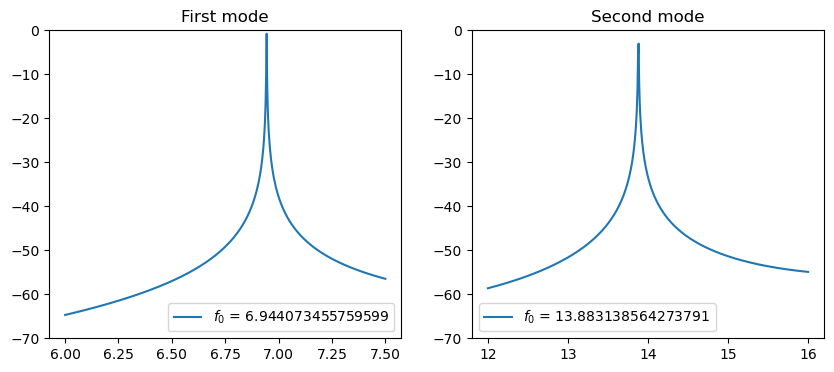

In [176]:
data1 = np.loadtxt('simulation 1 resonator - half wave mode.txt').T
data2 = np.loadtxt('simulation 1 resonator - full wave mode.txt').T

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

x_max = data1[0][np.argmax(data1[1])]
print('freq 1: ',x_max)

ax[0].plot(data1[0],data1[1], label=f'$f_0$ = {x_max}')
ax[0].set_ylim(-70,0)
ax[0].set_title('First mode')
ax[0].legend()
#######################################################

x_max = data2[0][np.argmax(data2[1])]
print('freq 2: ',x_max)

ax[1].plot(data2[0],data2[1], label=f'$f_0$ = {x_max}')
ax[1].set_ylim(-70,0)
ax[1].set_title('Second mode')
ax[1].legend()



# Hexagono

calcula t

In [177]:
f_ghz=13.88 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=6.4e-15 #F
l= 8.7*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

-0.060062204192021636

cria a matriz com os elementos diferentes de zero e coloca o valor de t ali

fazer a matriz hexagono 


In [178]:

indexes = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(1,0),(2,1),(3,2),(4,3),(5,4),(0,5)]
ALG = np.zeros((6,6))

for i in range(0,12):
    ALG[indexes[i][0]][indexes[i][1]] = 1

ALG


array([[0., 1., 0., 0., 0., 1.],
       [1., 0., 1., 0., 0., 0.],
       [0., 1., 0., 1., 0., 0.],
       [0., 0., 1., 0., 1., 0.],
       [0., 0., 0., 1., 0., 1.],
       [1., 0., 0., 0., 1., 0.]])

diagonaliza a matriz e recebe os autovalores dela

In [179]:
# list of eigenvalues

ev = np.sort(np.linalg.eigvals(ALG))
ev

array([-2., -1., -1.,  1.,  1.,  2.])

In [180]:
# Expeted frequencies

diagonal = f_ghz*np.ones(6)
H = -t*ALG
np.fill_diagonal(H,diagonal)

ideal_eigenv = np.sort(np.linalg.eigvals(H))
print(H, ideal_eigenv)

[[13.88       0.0600622  0.         0.         0.         0.0600622]
 [ 0.0600622 13.88       0.0600622  0.         0.         0.       ]
 [ 0.         0.0600622 13.88       0.0600622  0.         0.       ]
 [ 0.         0.         0.0600622 13.88       0.0600622  0.       ]
 [ 0.         0.         0.         0.0600622 13.88       0.0600622]
 [ 0.0600622  0.         0.         0.         0.0600622 13.88     ]] [13.75987559 13.8199378  13.8199378  13.9400622  13.9400622  14.00012441]


# Hexagono realista

In [181]:
f_ghz=13.568 # GHz segundo harmonico
f=f_ghz*1e9 # Hz
C=np.array([6.1, 6.54, 6.11, 6.11, 6.54, 6.11])*1e-15 - 0.5e-15 #F
l= 8.7*1e-3 # m
C_l=1.7e-10 # F/m
Z=50

t= -(1/2 * f*C*2/(C_l*l))*1e-9

t

array([-0.05137309, -0.05540955, -0.05146483, -0.05146483, -0.05540955,
       -0.05146483])

In [182]:

indexes = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,0),(1,0),(2,1),(3,2),(4,3),(5,4),(0,5)]
ALG = -np.zeros((6,6))

n = 0
for i in range(0,6):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1
n = 0
for i in range(6,12):
    ALG[indexes[i][0]][indexes[i][1]] = t[n]
    n += 1

diagonal = f_ghz*np.ones(6)
H = -ALG
np.fill_diagonal(H,diagonal)

hexagon_eigenv = np.sort(np.linalg.eigvals(H))
print(H, hexagon_eigenv)

[[13.568       0.05137309  0.          0.          0.          0.05146483]
 [ 0.05137309 13.568       0.05540955  0.          0.          0.        ]
 [ 0.          0.05540955 13.568       0.05146483  0.          0.        ]
 [ 0.          0.          0.05146483 13.568       0.05146483  0.        ]
 [ 0.          0.          0.          0.05146483 13.568       0.05540955]
 [ 0.05146483  0.          0.          0.          0.05540955 13.568     ]] [13.46244861 13.51259032 13.51785833 13.61814167 13.62340968 13.67355139]


## Resultado da simulação

(13.4, 13.7)

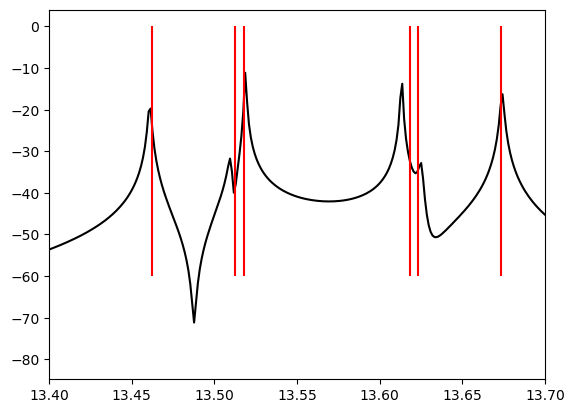

In [183]:
h21 = np.loadtxt('simulation hexagon S21.txt').T

plt.plot(h21[0],h21[1], 'k')
plt.vlines(hexagon_eigenv,-60, 0, 'r')

plt.xlim(13.4, 13.7)

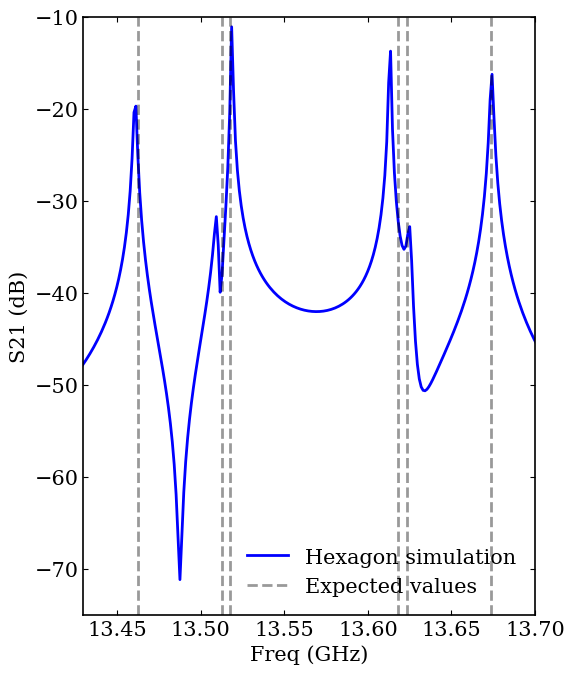

In [220]:
# ---------- Configuração estilo científico ----------
plt.rcParams.update({
    "font.size": 15,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
    "lines.markersize": 6,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "legend.frameon": False
})

# ---------- Figura ----------
fig, ax = plt.subplots(figsize=(6,7))

ax.plot(h21[0], h21[1], '-b', label="Hexagon simulation")

# ---------- Valores esperados ----------
for i, val in enumerate(hexagon_eigenv):
    plt.axvline(val, linestyle="--", color="black",
                alpha=0.4,
                label="Expected values" if i==0 else "")

# ---------- Eixos ----------
ax.set_xlabel("Freq (GHz)")
ax.set_ylabel("S21 (dB)")

# ---------- Limites ----------
ax.set_xlim(13.43, 13.7)
ax.set_ylim(-75,-10)

# ---------- Grade opcional ----------
#ax.grid(alpha=0.3)

# ---------- Legenda ----------
ax.legend()

# ---------- Ajuste layout ----------
plt.tight_layout()

# ---------- Salvar figura ----------
plt.savefig("grafico_artigo.png", dpi=600)

plt.show()

# Rede grafeno

fazer para os 19 hexagonos

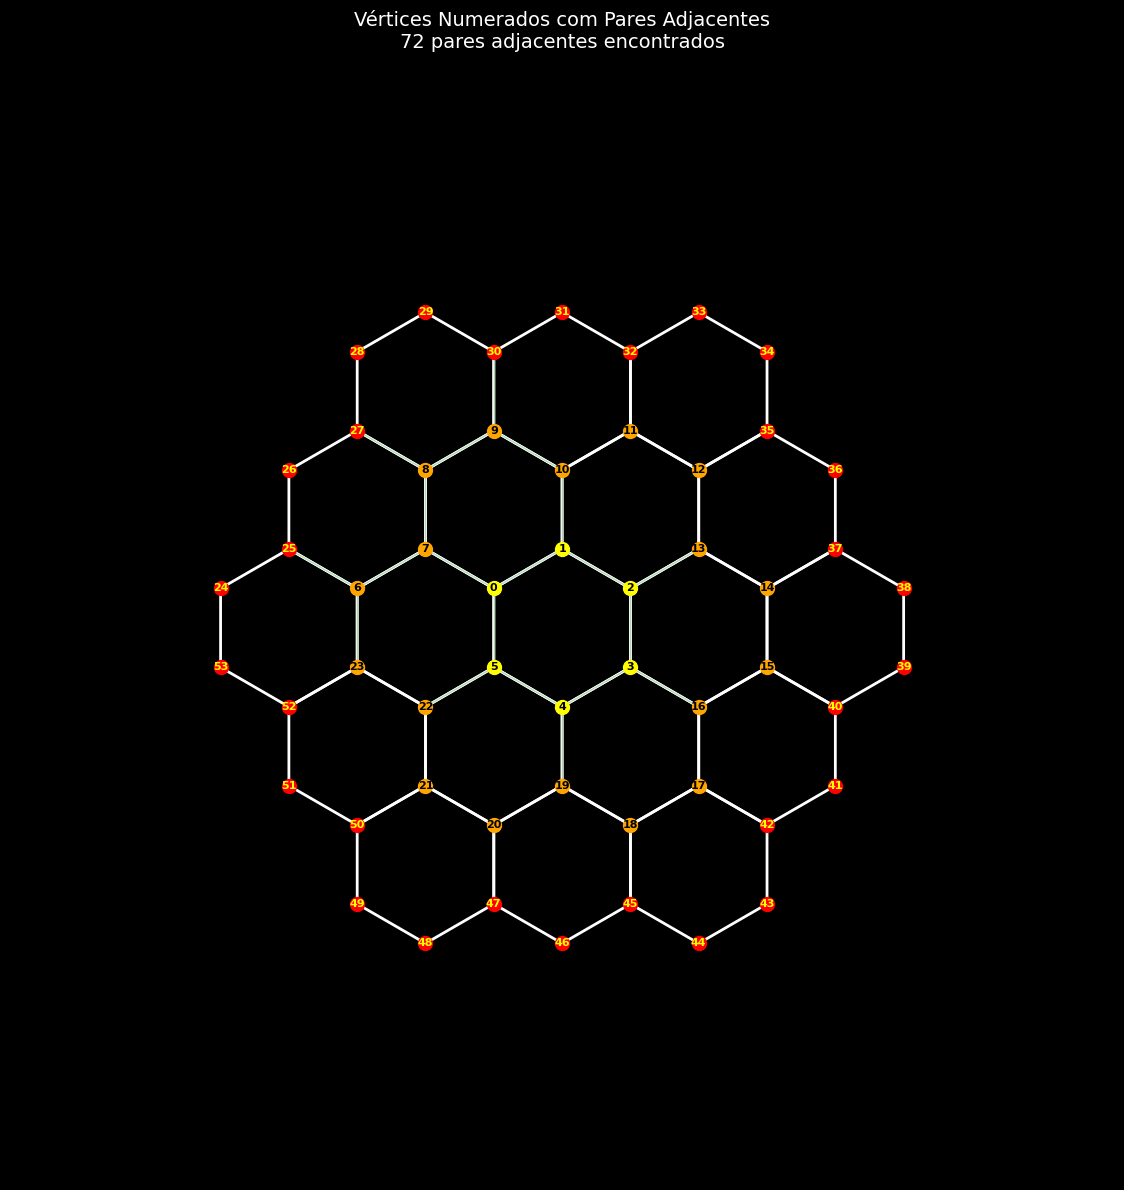

=== LISTA COMPLETA DE PARES DE VÉRTICES ADJACENTES ===
Total de pares adjacentes: 72

Formato: (vértice1, vértice2)
Par  1: ( 0,  1)
Par  2: ( 0,  5)
Par  3: ( 0,  7)
Par  4: ( 1,  2)
Par  5: ( 1, 10)
Par  6: ( 2,  3)
Par  7: ( 2, 13)
Par  8: ( 3,  4)
Par  9: ( 3, 16)
Par 10: ( 4,  5)
Par 11: ( 4, 19)
Par 12: ( 5, 22)
Par 13: ( 6,  7)
Par 14: ( 6, 23)
Par 15: ( 6, 25)
Par 16: ( 7,  8)
Par 17: ( 8,  9)
Par 18: ( 8, 27)
Par 19: ( 9, 10)
Par 20: ( 9, 30)
Par 21: (10, 11)
Par 22: (11, 12)
Par 23: (11, 32)
Par 24: (12, 13)
Par 25: (12, 35)
Par 26: (13, 14)
Par 27: (14, 15)
Par 28: (14, 37)
Par 29: (15, 16)
Par 30: (15, 40)
Par 31: (16, 17)
Par 32: (17, 18)
Par 33: (17, 42)
Par 34: (18, 19)
Par 35: (18, 45)
Par 36: (19, 20)
Par 37: (20, 21)
Par 38: (20, 47)
Par 39: (21, 22)
Par 40: (21, 50)
Par 41: (22, 23)
Par 42: (23, 52)
Par 43: (24, 25)
Par 44: (24, 53)
Par 45: (25, 26)
Par 46: (26, 27)
Par 47: (27, 28)
Par 48: (28, 29)
Par 49: (29, 30)
Par 50: (30, 31)
Par 51: (31, 32)
Par 52: (32, 33)


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import RegularPolygon

# Configurar figura (fundo preto)
fig, ax = plt.subplots(figsize=(12, 12))
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.axis('off')
ax.set_facecolor('black')
fig.patch.set_facecolor('black')

# Parâmetros
radius = 0.5
spacing = radius * np.sqrt(3)
height = radius * 1.5

# Coordenadas dos 19 hexágonos
positions = [
    (0, 0),  # centro
    # Anel interno
    (spacing, 0), (spacing/2, height), (-spacing/2, height),
    (-spacing, 0), (-spacing/2, -height), (spacing/2, -height),
    # Anel externo
    (2*spacing, 0), (1.5*spacing, height), (spacing, 2*height),
    (0, 2*height), (-spacing, 2*height), (-1.5*spacing, height),
    (-2*spacing, 0), (-1.5*spacing, -height), (-spacing, -2*height),
    (0, -2*height), (spacing, -2*height), (1.5*spacing, -height)
]

# Desenhar hexágonos
for x, y in positions:
    hex = RegularPolygon((x, y), 6, radius=radius, 
                        facecolor='none', edgecolor='white', linewidth=2)
    ax.add_patch(hex)

# Função para obter vértices de um hexágono
def get_hex_vertices(center_x, center_y, radius):
    vertices = []
    for i in range(6):
        angle = i * np.pi / 3 + np.pi/2  # +90° para ter vértice no topo
        x = center_x + radius * np.cos(angle)
        y = center_y + radius * np.sin(angle)
        vertices.append((x, y))
    return vertices

# Coletar TODOS os vértices únicos com seus índices
all_vertices = []
tolerance = 0.02

# Para cada hexágono, coletar todos os vértices
for i, (hex_x, hex_y) in enumerate(positions):
    vertices = get_hex_vertices(hex_x, hex_y, radius)
    
    for vertex in vertices:
        # Verificar se já não temos esse vértice (evitar duplicatas)
        is_duplicate = False
        for existing_vertex in all_vertices:
            if abs(vertex[0] - existing_vertex[0]) < tolerance and \
               abs(vertex[1] - existing_vertex[1]) < tolerance:
                is_duplicate = True
                break
        
        if not is_duplicate:
            all_vertices.append(vertex)

# Classificar e ordenar vértices (mesmo código original)
def classify_vertex(vertex):
    distance_from_center = np.sqrt(vertex[0]**2 + vertex[1]**2)
    
    if distance_from_center < 0.6:  # Centro
        return "center"
    elif distance_from_center < 1.4:  # Interno
        return "internal"
    else:  # Externo
        return "external"

center_vertices = []
internal_vertices = []
external_vertices = []

for vertex in all_vertices:
    category = classify_vertex(vertex)
    if category == "center":
        center_vertices.append(vertex)
    elif category == "internal":
        internal_vertices.append(vertex)
    else:
        external_vertices.append(vertex)

def sort_clockwise(vertices, center=(0, 0)):
    def get_angle(vertex):
        return np.arctan2(vertex[1] - center[1], vertex[0] - center[0])
    
    sorted_vertices = sorted(vertices, key=get_angle)
    return sorted_vertices[::-1]

center_vertices_sorted = sort_clockwise(center_vertices)
internal_vertices_sorted = sort_clockwise(internal_vertices)
external_vertices_sorted = sort_clockwise(external_vertices)

all_vertices_ordered = center_vertices_sorted + internal_vertices_sorted + external_vertices_sorted

# Criar mapeamento de coordenadas para índices
vertex_to_index = {}
for i, vertex in enumerate(all_vertices_ordered):
    vertex_to_index[vertex] = i

# Função para encontrar vértices adjacentes
def find_adjacent_pairs():
    adjacent_pairs = []
    adjacency_tolerance = radius + 0.01  # Distância máxima para considerar adjacente
    
    # Para cada hexágono, encontrar as arestas (pares de vértices consecutivos)
    for hex_idx, (hex_x, hex_y) in enumerate(positions):
        hex_vertices = get_hex_vertices(hex_x, hex_y, radius)
        
        # Para cada aresta do hexágono (vértices consecutivos)
        for i in range(6):
            v1 = hex_vertices[i]
            v2 = hex_vertices[(i + 1) % 6]  # Próximo vértice (circular)
            
            # Encontrar os índices destes vértices na lista ordenada
            idx1 = None
            idx2 = None
            
            for vertex, idx in vertex_to_index.items():
                if abs(vertex[0] - v1[0]) < tolerance and abs(vertex[1] - v1[1]) < tolerance:
                    idx1 = idx
                if abs(vertex[0] - v2[0]) < tolerance and abs(vertex[1] - v2[1]) < tolerance:
                    idx2 = idx
            
            # Se encontrou ambos os vértices, adicionar o par
            if idx1 is not None and idx2 is not None:
                # Ordenar para evitar pares duplicados (menor, maior)
                pair = tuple(sorted([idx1, idx2]))
                if pair not in adjacent_pairs:
                    adjacent_pairs.append(pair)
    
    return sorted(adjacent_pairs)

# Encontrar todos os pares adjacentes
adjacent_pairs = find_adjacent_pairs()

# Visualizar os vértices numerados
colors = {"center": "yellow", "internal": "orange", "external": "red"}
text_colors = {"center": "black", "internal": "black", "external": "yellow"}

for i, vertex in enumerate(all_vertices_ordered):
    category = classify_vertex(vertex)
    ax.plot(vertex[0], vertex[1], 'o', color=colors[category], markersize=10, zorder=10)
    ax.text(vertex[0], vertex[1], str(i), color=text_colors[category], 
            fontsize=8, fontweight='bold', ha='center', va='center', zorder=11)

# Desenhar algumas arestas para visualização (opcional - pode comentar se ficar muito poluído)
for i, (v1_idx, v2_idx) in enumerate(adjacent_pairs[:20]):  # Mostrar apenas as primeiras 20
    v1 = all_vertices_ordered[v1_idx]
    v2 = all_vertices_ordered[v2_idx]
    ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 'g-', alpha=0.3, linewidth=1, zorder=5)

plt.title(f'Vértices Numerados com Pares Adjacentes\n{len(adjacent_pairs)} pares adjacentes encontrados', 
          color='white', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Imprimir a lista de todos os pares adjacentes
print("=== LISTA COMPLETA DE PARES DE VÉRTICES ADJACENTES ===")
print(f"Total de pares adjacentes: {len(adjacent_pairs)}")
print("\nFormato: (vértice1, vértice2)")
print("=" * 50)

for i, (v1, v2) in enumerate(adjacent_pairs):
    print(f"Par {i+1:2d}: ({v1:2d}, {v2:2d})")

# Criar lista Python para fácil cópia
print("\n=== LISTA EM FORMATO PYTHON ===")
print("adjacent_pairs = [")
for i, pair in enumerate(adjacent_pairs):
    if i == len(adjacent_pairs) - 1:
        print(f"    {pair}")
    else:
        print(f"    {pair},")
print("]")

# Estatísticas adicionais
print(f"\n=== ESTATÍSTICAS ===")
print(f"Total de vértices: {len(all_vertices_ordered)}")
print(f"Total de pares adjacentes: {len(adjacent_pairs)}")
print(f"Grau médio: {2 * len(adjacent_pairs) / len(all_vertices_ordered):.2f}")

# Verificar conectividade de cada vértice
vertex_connections = {}
for v1, v2 in adjacent_pairs:
    vertex_connections[v1] = vertex_connections.get(v1, 0) + 1
    vertex_connections[v2] = vertex_connections.get(v2, 0) + 1

print(f"\nDistribuição de graus:")
degree_distribution = {}
for vertex, degree in vertex_connections.items():
    degree_distribution[degree] = degree_distribution.get(degree, 0) + 1

for degree in sorted(degree_distribution.keys()):
    print(f"Grau {degree}: {degree_distribution[degree]} vértices")

adjacent_pairs = [
    (0, 1), (0, 5), (0, 7), (1, 2), (1, 10), (2, 3), (2, 13), (3, 4), (3, 16), (4, 5),
    (4, 19), (5, 22), (6, 7), (6, 23), (6, 25), (7, 8), (8, 9), (8, 27), (9, 10), (9, 30),
    (10, 11), (11, 12), (11, 32), (12, 13), (12, 35), (13, 14), (14, 15), (14, 37), (15, 16),
    (15, 40), (16, 17), (17, 18), (17, 42), (18, 19), (18, 45), (19, 20), (20, 21), (20, 47),
    (21, 22), (21, 50), (22, 23), (23, 52), (24, 25), (24, 53), (25, 26), (26, 27), (27, 28),
    (28, 29), (29, 30), (30, 31), (31, 32), (32, 33), (33, 34), (34, 35), (35, 36), (36, 37),
    (37, 38), (38, 39), (39, 40), (40, 41), (41, 42), (42, 43), (43, 44), (44, 45), (45, 46),
    (46, 47), (47, 48), (48, 49), (49, 50), (50, 51), (51, 52), (52, 53)
]

In [10]:


# Parâmetros
f_ghz = 6.9  # Frequência em GHz
t = -0.027991886409736308     

# Pares adjacentes dos hexágonos
indexes = [
    (0, 1), (0, 5), (0, 7), (1, 2), (1, 10), (2, 3), (2, 13), (3, 4), (3, 16), (4, 5),
    (4, 19), (5, 22), (6, 7), (6, 23), (6, 25), (7, 8), (8, 9), (8, 27), (9, 10), (9, 30),
    (10, 11), (11, 12), (11, 32), (12, 13), (12, 35), (13, 14), (14, 15), (14, 37), (15, 16),
    (15, 40), (16, 17), (17, 18), (17, 42), (18, 19), (18, 45), (19, 20), (20, 21), (20, 47),
    (21, 22), (21, 50), (22, 23), (23, 52), (24, 25), (24, 53), (25, 26), (26, 27), (27, 28),
    (28, 29), (29, 30), (30, 31), (31, 32), (32, 33), (33, 34), (34, 35), (35, 36), (36, 37),
    (37, 38), (38, 39), (39, 40), (40, 41), (41, 42), (42, 43), (43, 44), (44, 45), (45, 46),
    (46, 47), (47, 48), (48, 49), (49, 50), (50, 51), (51, 52), (52, 53)
]

# Matriz de adjacência 54x54 (em vez de 5x5 do pentágono)
ALG = np.zeros((54, 54))
for i in range(len(indexes)):
    ALG[indexes[i][0]][indexes[i][1]] = 1
    ALG[indexes[i][1]][indexes[i][0]] = 1

# Expected frequencies
diagonal = f_ghz * np.ones(54)  # 54 vértices em vez de 5
#H = -t * ALG
#np.fill_diagonal(H, diagonal)
print(ALG)
eigenv = np.sort(np.linalg.eigvals(ALG))
print(f"Dimensão: {H.shape}")


print("\nAutovalores (frequências):")
print(eigenv)

[[0. 1. 0. ... 0. 0. 0.]
 [1. 0. 1. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 1. 0. 1.]
 [0. 0. 0. ... 0. 1. 0.]]
Dimensão: (54, 54)

Autovalores (frequências):
[-2.84014622 -2.60368504 -2.60368504 -2.30948    -2.30948    -2.21551556
 -2.         -1.94055219 -1.8053019  -1.8053019  -1.60573313 -1.60573313
 -1.39153498 -1.39153498 -1.35263875 -1.23751065 -1.23751065 -1.04636775
 -1.         -1.         -1.         -1.         -0.68179049 -0.68179049
 -0.57861941 -0.342041   -0.342041    0.342041    0.342041    0.57861941
  0.68179049  0.68179049  1.          1.          1.          1.
  1.04636775  1.23751065  1.23751065  1.35263875  1.39153498  1.39153498
  1.60573313  1.60573313  1.8053019   1.8053019   1.94055219  2.
  2.21551556  2.30948     2.30948     2.60368504  2.60368504  2.84014622]


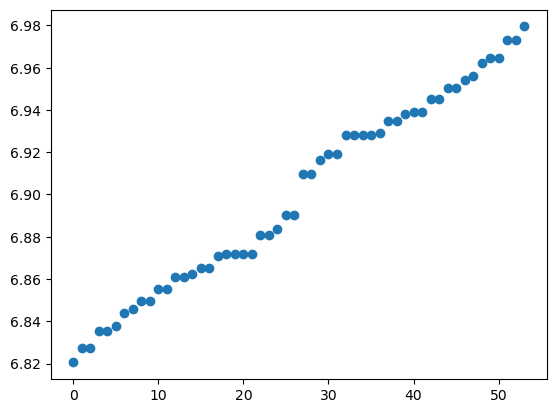

In [9]:
indice = np.arange(0,54)
plt.scatter(indice, eigenv)